# Inverse kinematics fit from the fly hackathon

In [1]:
from os import path as op
import sys
# sys.path.insert(0, op.abspath('/Users/eabe/Research/MyRepos/BiomechControl/models/fruitfly_v2/'))
sys.path.insert(0, op.abspath('/Users/eabe/Research/Github/flybody'))

from pathlib import Path
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import PIL.ImageDraw
from tqdm import tqdm

from dm_control import mujoco
from dm_control import mjcf
from dm_control.mujoco.wrapper.mjbindings import enums
from dm_control.mujoco.wrapper import mjbindings

import sys
sys.path.append('..')
# from dm_control.utils.inverse_kinematics import qpos_from_site_pose
from flybody.inverse_kinematics import qpos_from_site_xpos
from flybody.utils import display_video
from flybody.tasks.task_utils import retract_wings

In [2]:
def transform_frame(frame):
    """Transform a single frame from data to model reference frame."""
    # Rotate around z-axis.
    frame = frame[:, [1, 0, 2]]
    frame[:, 1] *= -1
    # Change units mm to cm.
    frame *= 0.1
    return frame

# Load a single walking sequence

In [3]:
base_path = Path('/Users/eabe/Research/MyRepos/mujoco_mpc/Archive/fruitfly')
task_path = Path('/Users/eabe/Research/MyRepos/mujoco_mpc/mjpc/tasks/fruitfly/flyqpos2')

data_path = base_path / 'combined_wt_berlin_walking_v3.pq'
full_df = pd.read_parquet(data_path, engine='pyarrow')
bout_stats = full_df.groupby(['walking_bout_number','fullfile','Sex'])[['fictrac_delta_rot_lab_y_mms', 'fictrac_delta_rot_lab_z_deg/s']].agg(['mean','min','max','std','count'])
fast = (bout_stats[('fictrac_delta_rot_lab_y_mms','mean')] >= 12) & (bout_stats[('fictrac_delta_rot_lab_y_mms','min')] >= 10)
straight = (bout_stats[('fictrac_delta_rot_lab_z_deg/s','mean')].abs() <= 45) &\
           (bout_stats[('fictrac_delta_rot_lab_z_deg/s','min')] >= -60) &\
           (bout_stats[('fictrac_delta_rot_lab_z_deg/s','max')] <= 60)

#minlen =  bout_stats[('fictrac_delta_rot_lab_z_deg/s','count')] >= 300
# bout_stats[fast & straight].sort_values(('fictrac_delta_rot_lab_y_mms','min')).loc['walking_bout_number']

In [4]:
tredmill_df = pd.read_csv(base_path/'wt_berlin_linear_treadmill_dataset.csv')

In [4]:
tredmill_df['top front chamber_x']

NameError: name 'tredmill_df' is not defined

In [10]:
kp_names = ['head', 'thorax', 'abdomen', 'r1', 'r2', 'r3', 'l1', 'l2', 'l3']
coords = ['_x', '_y', '_z']
df_names = [kp+coord for kp in kp_names for coord in coords]

In [11]:
tredmill_df[df_names]

,head_x,head_y,head_z,thorax_x,thorax_y,thorax_z,abdomen_x,abdomen_y,abdomen_z,r1_x,...,r3_z,l1_x,l1_y,l1_z,l2_x,l2_y,l2_z,l3_x,l3_y,l3_z
0,3.450135,0.873035,-0.370879,2.999044,0.617059,-0.318665,2.591663,0.467626,-0.616344,3.855535,...,-0.719721,3.543946,1.134848,-0.756548,2.592618,1.160497,-0.699474,2.312224,0.713110,-0.721703
1,3.454003,0.864033,-0.368180,2.997850,0.617182,-0.316033,2.587607,0.478776,-0.614386,3.824447,...,-0.720182,3.528529,1.125173,-0.763366,2.750468,1.098510,-0.747855,2.304739,0.727513,-0.711848
2,3.458119,0.851936,-0.368378,2.995280,0.618721,-0.314397,2.585179,0.488403,-0.616769,3.807999,...,-0.721979,3.511187,1.118431,-0.772809,2.850862,1.081000,-0.788593,2.299042,0.736405,-0.705374
3,3.463930,0.833212,-0.371491,2.992199,0.619036,-0.312403,2.582698,0.495596,-0.618907,3.803716,...,-0.723189,3.494780,1.112430,-0.782207,2.902092,1.096943,-0.814111,2.290965,0.734075,-0.707693
4,3.472447,0.800972,-0.375278,2.989791,0.610978,-0.307717,2.579848,0.496213,-0.617606,3.809630,...,-0.722732,3.487213,1.100307,-0.782938,2.922530,1.130531,-0.815793,2.280308,0.720488,-0.718276
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1045795,2.214218,0.742215,-0.420974,1.798322,0.551664,-0.287553,1.450423,0.380235,-0.576440,2.423245,...,-0.717700,2.195885,1.008046,-0.825808,1.519869,1.035478,-0.630253,1.273246,0.677763,-0.756106
1045796,2.207361,0.742682,-0.415473,1.787152,0.557071,-0.288324,1.440377,0.389042,-0.580543,2.489224,...,-0.659248,2.154520,1.025012,-0.814412,1.649911,1.012908,-0.663707,1.227637,0.710214,-0.736885
1045797,2.205576,0.744050,-0.410042,1.782817,0.563458,-0.285759,1.438634,0.398010,-0.581211,2.534301,...,-0.582622,2.120276,1.055111,-0.792089,1.747369,0.987043,-0.749077,1.184263,0.723813,-0.736786
1045798,2.209623,0.750015,-0.410027,1.788055,0.567837,-0.285079,1.444255,0.403379,-0.581758,2.539784,...,-0.559107,2.098911,1.087568,-0.766872,1.777902,0.963704,-0.829726,1.149277,0.722058,-0.742554


In [7]:
tredmill_df.columns

Index(['genotype', 'filename', 'fly number', 'trial number',
       'belt speed (mm/s)', 'frame start of steady-state belt speed',
       'top front chamber_x', 'top front chamber_y', 'top front chamber_z',
       'top front chamber_error', 'top front chamber_ncams',
       'top front chamber_score', 'top back chamber_x', 'top back chamber_y',
       'top back chamber_z', 'top back chamber_error',
       'top back chamber_ncams', 'top back chamber_score',
       'back center chamber_x', 'back center chamber_y',
       'back center chamber_z', 'back center chamber_error',
       'back center chamber_ncams', 'back center chamber_score', 'head_x',
       'head_y', 'head_z', 'head_error', 'head_ncams', 'head_score',
       'thorax_x', 'thorax_y', 'thorax_z', 'thorax_error', 'thorax_ncams',
       'thorax_score', 'abdomen_x', 'abdomen_y', 'abdomen_z', 'abdomen_error',
       'abdomen_ncams', 'abdomen_score', 'r1_x', 'r1_y', 'r1_z', 'r1_error',
       'r1_ncams', 'r1_score', 'r2_x', 'r2_y', 

In [4]:
legs = ['T1_left', 'T1_right', 'T2_left', 'T2_right', 'T3_left', 'T3_right']
joints = ['coxa', 'femur', 'tibia', 'tarsus']
xpos_geoms = ['coxa', 'femur', 'tibia', 'tarsus', 'claw']
joint_names = [f'{joint}_{leg}' for leg in legs for joint in joints]
xpos_names = [f'{joint}_{leg}' for leg in legs for joint in xpos_geoms]
# physics.named.data.framepos[pos_names]
site_names = [f'tracking[{joint_name}]' for joint_name in xpos_names]

legs_data = ['L1', 'R1', 'L2','R2', 'L3','R3']
joints_data = ['A','B','C','D','E']
coords_data = ['_x','_y','_z']
joint_pos_columns = [leg + joint + coord 
                     for leg in legs_data
                     for joint in joints_data 
                     for coord in coords_data]

straight_bouts = bout_stats[fast & straight].index
straight_bout_num = np.array([i[0] for i in straight_bouts],dtype=int)
mean_straight_bout = (full_df[full_df['walking_bout_number'] == 14574][joint_pos_columns].values.reshape(-1,30, 3)).mean(axis=0)
ref_bout = (full_df[full_df['walking_bout_number'] == 14574][joint_pos_columns].values.reshape(-1,30, 3))
bout_dict = {'walking_bout{:02}'.format(n):{} for n in range(len(straight_bout_num))}

for n, bout_num in enumerate(straight_bout_num):
    bout = full_df[full_df['walking_bout_number'] == bout_num]
    bout_dict['walking_bout{:02}'.format(n)]['orig_xpos'] = bout[joint_pos_columns].values.reshape(-1,30, 3)
    bout_dict['walking_bout{:02}'.format(n)]['orig_xpos'] = bout_dict['walking_bout{:02}'.format(n)]['orig_xpos'] + (mean_straight_bout-np.mean(bout_dict['walking_bout{:02}'.format(n)]['orig_xpos'],axis=0))

In [4]:
walking_bout_n = 1
df = full_df[full_df['walking_bout_number'] == 14574]
df.shape

(181, 452)

In [ ]:
# full_df['walking_bout_number'].unique()
walking_bout_n = 2
df = full_df[full_df['walking_bout_number'] == 2244]
df.shape

In [23]:
df = full_df[full_df['walking_bout_number'] == 3962]
df.shape

(601, 452)

In [ ]:
joint_names_df = ['{}{}_{}'.format(leg, joint, axis) for leg in legs_data for joint in ['A', 'B', 'C', 'D'] for axis in ['abduct', 'flex', 'rot'] if '{}{}_{}'.format(leg, joint, axis) in df.columns]
joint_names_df = [joint_names_df[n] for n in range(len(joint_names_df)) if 'C_rot' not in joint_names_df[n]]
# joint_names_mujoco = ['{}{}_{}'.format(leg, joint, axis) for leg in legs for joint in ['A', 'B', 'C', 'D'] for axis in ['abduct', 'flex', 'rot'] if '{}{}_{}'.format(leg, joint, axis) in df.columns]

In [5]:
joints_to_manipulate = ['coxa_abduct_T1_left',  'coxa_twist_T1_left',   'coxa_T1_left',   'femur_T1_left',  'femur_twist_T1_left',  'tibia_T1_left',    'tarsus_T1_left',
                        'coxa_abduct_T1_right', 'coxa_twist_T1_right',  'coxa_T1_right',  'femur_T1_right', 'femur_twist_T1_right', 'tibia_T1_right',   'tarsus_T1_right',
                        'coxa_abduct_T2_left',  'coxa_twist_T2_left',   'coxa_T2_left',   'femur_T2_left',  'femur_twist_T2_left',  'tibia_T2_left',    'tarsus_T2_left',
                        'coxa_abduct_T2_right', 'coxa_twist_T2_right',  'coxa_T2_right',  'femur_T2_right', 'femur_twist_T2_right', 'tibia_T2_right',   'tarsus_T2_right',
                        'coxa_abduct_T3_left',  'coxa_twist_T3_left',   'coxa_T3_left',   'femur_T3_left',  'femur_twist_T3_left',  'tibia_T3_left',    'tarsus_T3_left',
                        'coxa_abduct_T3_right', 'coxa_twist_T3_right',  'coxa_T3_right',  'femur_T3_right', 'femur_twist_T3_right', 'tibia_T3_right',   'tarsus_T3_right',]

# Load the fly model

In [5]:
xml_path = task_path / 'task.xml'
# xml_path = task_path.parent / 'fruitfly_force.xml'
# xml_path = '/Users/eabe/Research/MyRepos/mujoco_mpc/mjpc/tasks/fruitfly/fruitfly_freeforce.xml'
mjcf_model = mjcf.from_path(xml_path)


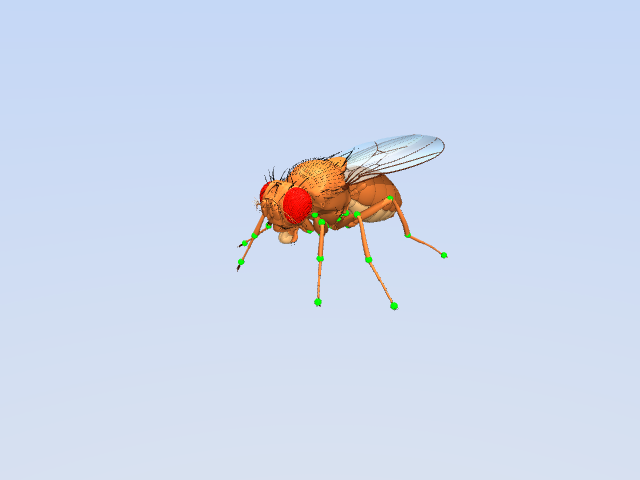

In [6]:
# Visualize fly as loaded.
physics = mjcf.Physics.from_mjcf_model(mjcf_model)
# physics.model.geom('floor').pos = (0, 0, -.137)
_ = physics.reset()
# retract_wings(physics, prefix='')
# physics.step()
pixels = physics.render(camera_id=1, width=640, height=480)
PIL.Image.fromarray(pixels)

In [8]:
physics.named.data.qpos['coxa_abduct_T2_left']

array([0.])

In [9]:
legs = ['T1_left', 'T1_right', 'T2_left', 'T2_right', 'T3_left', 'T3_right']
joints = ['coxa', 'femur', 'tibia', 'tarsus']
xpos_geoms = ['coxa', 'femur', 'tibia', 'tarsus', 'claw']
joint_names = [f'{joint}_{leg}' for leg in legs for joint in joints]
xpos_names = [f'{joint}_{leg}' for leg in legs for joint in xpos_geoms]
# physics.named.data.framepos[pos_names]
site_names = [f'tracking[{joint_name}]' for joint_name in xpos_names]

legs_data = ['L1', 'R1', 'L2','R2', 'L3','R3']
joints_data = ['A','B','C','D','E']
coords_data = ['_x','_y','_z']
joint_pos_columns = [leg + joint + coord 
                     for leg in legs_data
                     for joint in joints_data 
                     for coord in coords_data]

joints_to_manipulate = ['coxa_abduct_T1_left',  'coxa_twist_T1_left',   'coxa_T1_left',   'femur_T1_left',  'femur_twist_T1_left',  'tibia_T1_left',    'tarsus_T1_left',
                        'coxa_abduct_T1_right', 'coxa_twist_T1_right',  'coxa_T1_right',  'femur_T1_right', 'femur_twist_T1_right', 'tibia_T1_right',   'tarsus_T1_right',
                        'coxa_abduct_T2_left',  'coxa_twist_T2_left',   'coxa_T2_left',   'femur_T2_left',  'femur_twist_T2_left',  'tibia_T2_left',    'tarsus_T2_left',
                        'coxa_abduct_T2_right', 'coxa_twist_T2_right',  'coxa_T2_right',  'femur_T2_right', 'femur_twist_T2_right', 'tibia_T2_right',   'tarsus_T2_right',
                        'coxa_abduct_T3_left',  'coxa_twist_T3_left',   'coxa_T3_left',   'femur_T3_left',  'femur_twist_T3_left',  'tibia_T3_left',    'tarsus_T3_left',
                        'coxa_abduct_T3_right', 'coxa_twist_T3_right',  'coxa_T3_right',  'femur_T3_right', 'femur_twist_T3_right', 'tibia_T3_right',   'tarsus_T3_right',]


In [10]:

joints_to_manipulate = ['coxa_abduct_T1_left',  'coxa_twist_T1_left',   'coxa_T1_left',   'femur_T1_left',  'femur_twist_T1_left',  'tibia_T1_left',    'tarsus_T1_left',
                        'coxa_abduct_T1_right', 'coxa_twist_T1_right',  'coxa_T1_right',  'femur_T1_right', 'femur_twist_T1_right', 'tibia_T1_right',   'tarsus_T1_right',
                        'coxa_abduct_T2_left',  'coxa_twist_T2_left',   'coxa_T2_left',   'femur_T2_left',  'femur_twist_T2_left',  'tibia_T2_left',    'tarsus_T2_left',
                        'coxa_abduct_T2_right', 'coxa_twist_T2_right',  'coxa_T2_right',  'femur_T2_right', 'femur_twist_T2_right', 'tibia_T2_right',   'tarsus_T2_right',
                        'coxa_abduct_T3_left',  'coxa_twist_T3_left',   'coxa_T3_left',   'femur_T3_left',  'femur_twist_T3_left',  'tibia_T3_left',    'tarsus_T3_left',
                        'coxa_abduct_T3_right', 'coxa_twist_T3_right',  'coxa_T3_right',  'femur_T3_right', 'femur_twist_T3_right', 'tibia_T3_right',   'tarsus_T3_right',]

for nbout,bout in enumerate(bout_dict.keys()):
    _ = physics.reset()
    # retract_wings(physics, prefix='')
    site_pos = physics.named.data.site_xpos[site_names]
    qpos = []
    all_frames = []
    for i in tqdm(range(bout_dict[bout]['orig_xpos'].shape[0])):
        # Prepare frame for fitting.
        frame = bout_dict[bout]['orig_xpos'][i] #(keypoint, xyz)
        frame = transform_frame(frame)
        frame += site_pos[0, :]  # Shift to body-coxa T1 left joint.
        all_frames.append(frame)
        # _ = physics.reset()
        # Run IK fit on current frame.
        res = qpos_from_site_xpos(physics, site_names, frame, joints_to_manipulate, inplace=True)
        # Store qpos results.
        qpos.append(res.qpos.copy())
    all_frames = np.stack(all_frames)
    qpos = np.stack(qpos)
    bout_dict[bout]['inv_xpos'] = all_frames
    bout_dict[bout]['inv_qpos'] = qpos  

100%|██████████| 601/601 [01:11<00:00,  8.43it/s]


In [189]:
bout_dict[bout]['inv_qpos'].shape

(601, 70)

In [ ]:
with physics.reset_context():
    physics.data.qpos = bout_dict['walking_bout{:02}'.format(8)]['inv_qpos'][0].copy()
pixels = physics.render(camera_id=1, width=640, height=480)
PIL.Image.fromarray(pixels)

In [187]:
import io_dict_to_hdf5 as ioh5
ioh5.save('./bout_dict_free.h5',bout_dict,)

# Generate joint sequences in model and data in matching order

In [26]:
joint_names_df = ['{}{}_{}'.format(leg, joint, axis) for leg in legs_data for joint in ['A', 'B', 'C', 'D'] for axis in ['abduct', 'flex', 'rot'] if '{}{}_{}'.format(leg, joint, axis) in df.columns]
joint_names_df = [joint_names_df[n] for n in range(len(joint_names_df)) if 'C_rot' not in joint_names_df[n]]

bout_list = [14574,3962]
kp_tracking = {}
kp_tracking['joint_pos_columns'] = joint_pos_columns
for nbout,wbout in enumerate(bout_list):
    df = full_df[full_df['walking_bout_number'] == wbout]
    print(df.shape)
    kp_tracking['walking_{}_kp'.format(nbout)] = df[joint_pos_columns].values.reshape(-1,30, 3)
    kp_tracking['walking_{}_qpos'.format(nbout)] = df[joint_names_df].values.reshape(-1,6,7)

(181, 452)
(601, 452)


In [47]:
import io_dict_to_hdf5 as ioh5

In [48]:
ioh5.save('kp_tracking.h5', kp_tracking)

# Visualize a single frame

Text(0.5, 1.0, 'side view')

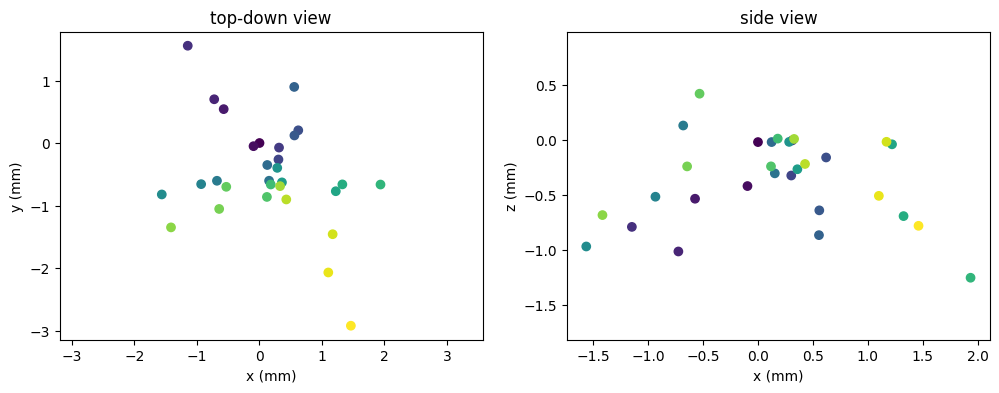

In [10]:
frame_idx = 0
test_frame = df[joint_pos_columns].values[frame_idx, :].reshape(30, 3)  # (keypoint, xyz)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.scatter(test_frame[:, 0], test_frame[:, 1], c=np.arange(30))
plt.axis('equal')
plt.xlabel('x (mm)')
plt.ylabel('y (mm)')
plt.title('top-down view')
plt.subplot(1, 2, 2)
plt.scatter(test_frame[:, 0], test_frame[:, 2], c=np.arange(30))
plt.axis('equal')
plt.xlabel('x (mm)')
plt.ylabel('z (mm)')
plt.title('side view')

# Compare model's initial position with first data frame

In [11]:
# Get the first frame.
frame0 = df[joint_pos_columns].values[0, :].reshape(30, 3)  # (keypoint, xyz)
frame0 = transform_frame(frame0)
site_pos = physics.named.data.site_xpos[site_names]
# Shift to match origin of data and model.
frame0 += site_pos[0, :]  # Body-coxa T1 left joint is the data origin.

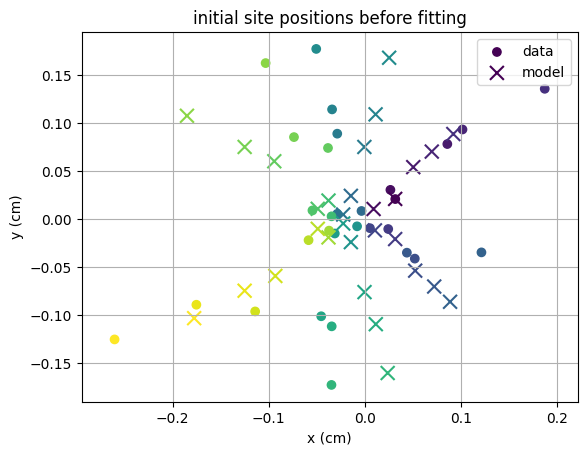

In [12]:
plt.scatter(frame0[:, 0], frame0[:, 1], c=np.arange(30), label='data')
plt.scatter(site_pos[:, 0], site_pos[:, 1], marker='x', s=100, c=np.arange(30), label='model')
plt.axis('equal')
plt.title('initial site positions before fitting')
plt.xlabel('x (cm)')
plt.ylabel('y (cm)')
plt.legend()
plt.grid()

# Try fitting one frame

In [13]:
# Manipulate all joints for now.
joints_to_manipulate = [j.name for j in mjcf_model.find_all('joint')]

In [14]:
frame0.shape, len(joints_to_manipulate), len(site_names)

((30, 3), 42, 30)

In [20]:
_ = physics.reset()
# retract_wings(physics, prefix='')

# Run IK fit on one frame.
res = qpos_from_site_xpos(physics, site_names, frame0, joints_to_manipulate, inplace=True)

In [16]:
joint_names = [
    "coxa_abduct_T1_left", "coxa_twist_T1_left", "coxa_T1_left", "femur_T1_left", "femur_twist_T1_left", "tibia_T1_left", "tarsus_T1_left", 
    "coxa_abduct_T1_right", "coxa_twist_T1_right", "coxa_T1_right", "femur_T1_right", "femur_twist_T1_right", "tibia_T1_right", "tarsus_T1_right", 
    "coxa_abduct_T2_left", "coxa_twist_T2_left", "coxa_T2_left", "femur_T2_left", "femur_twist_T2_left", "tibia_T2_left", "tarsus_T2_left", 
    "coxa_abduct_T2_right", "coxa_twist_T2_right", "coxa_T2_right", "femur_T2_right", "femur_twist_T2_right", "tibia_T2_right", "tarsus_T2_right",
    "coxa_abduct_T3_left", "coxa_twist_T3_left", "coxa_T3_left", "femur_T3_left", "femur_twist_T3_left", "tibia_T3_left", "tarsus_T3_left", 
    "coxa_abduct_T3_right", "coxa_twist_T3_right", "coxa_T3_right", "femur_T3_right", "femur_twist_T3_right", "tibia_T3_right", "tarsus_T3_right"
]

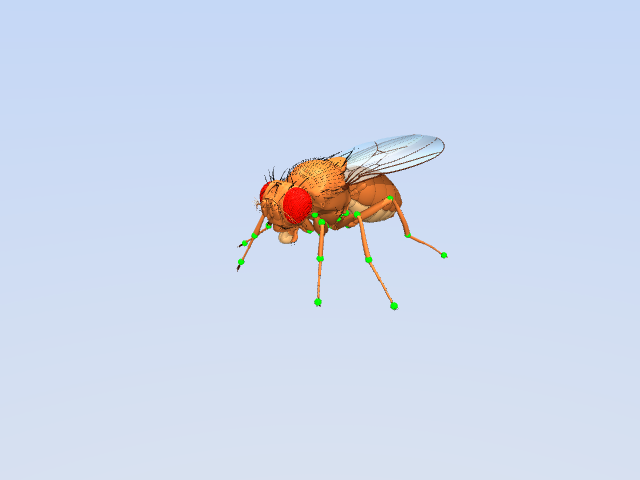

In [17]:
# Visualize fly as loaded.
physics = mjcf.Physics.from_mjcf_model(mjcf_model)
# physics.model.geom('floor').pos = (0, 0, -.137)
_ = physics.reset()
# retract_wings(physics, prefix='')
# physics.step()
pixels = physics.render(camera_id=1, width=640, height=480)
PIL.Image.fromarray(pixels)

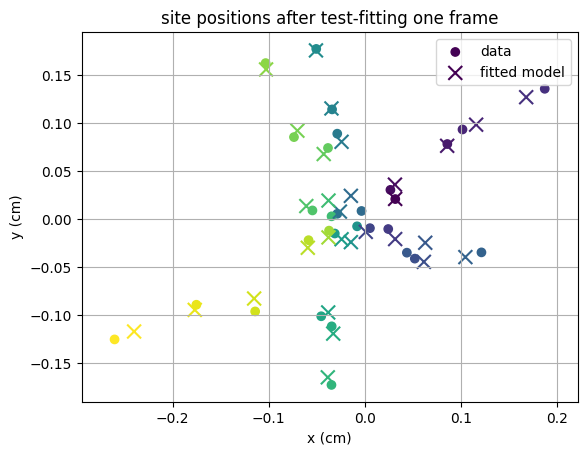

In [21]:
# Compare site positions after fitting.
site_pos = physics.named.data.site_xpos[site_names]
plt.scatter(frame0[:, 0], frame0[:, 1], c=np.arange(30), label='data')
plt.scatter(site_pos[:, 0], site_pos[:, 1], marker='x', s=100, c=np.arange(30), label='fitted model')
plt.axis('equal')
plt.title('site positions after test-fitting one frame')
plt.xlabel('x (cm)')
plt.ylabel('y (cm)')
plt.legend()
plt.grid()

In [ ]:
# #add ball
# texture = mjcf_model.asset.add('texture', rgb1=[.2, .3, .4], rgb2=[.1, .2, .3],
#                                type='2d', builtin='checker', name='groundplane',
#                                width=200, height=200,)
# material = mjcf_model.asset.add('material', name='ballsurface', 
#                                 texrepeat=[2, 2],  # Makes white squares exactly 1x1 length units.
#                                 texuniform=True,
#                                 reflectance=0.2,
#                                 texture=texture)

# # Remove freejoint.
# freejoint = mjcf_model.find('joint', 'free')
# if freejoint is not None:
#     freejoint.remove()
    
# # == Add ball.
# radius = 0.454  # Pick ball radius.
# # Calculate ball position wrt fly given ball radius.
# claw_T1_left = np.array([0.09178167, 0.08813114, -0.12480448])
# ball_x = - 0.05
# ball_z = - np.sqrt(radius**2 
#                    - (claw_T1_left[0] - ball_x)**2 
#                    - claw_T1_left[1]**2) + claw_T1_left[2]
# ball = mjcf_model.worldbody.add('body', name='ball', pos=(ball_x, 0, ball_z))
# ball.add('geom', type='sphere', size=(radius, 0, 0),
#          material=material, density=0.1)  # Density of water in cgs == 1.
# ball_joint = ball.add('joint', name='ball', type='ball')

# # Exclude "surprising collisions".
# for child in mjcf_model.find('body', 'thorax').all_children():
#     if child.tag == 'body':
#         mjcf_model.contact.add('exclude', name=f'thorax_{child.name}',
#                                body1='thorax', body2=child.name)

In [ ]:
for n in range(1, 100):
    physics.step()

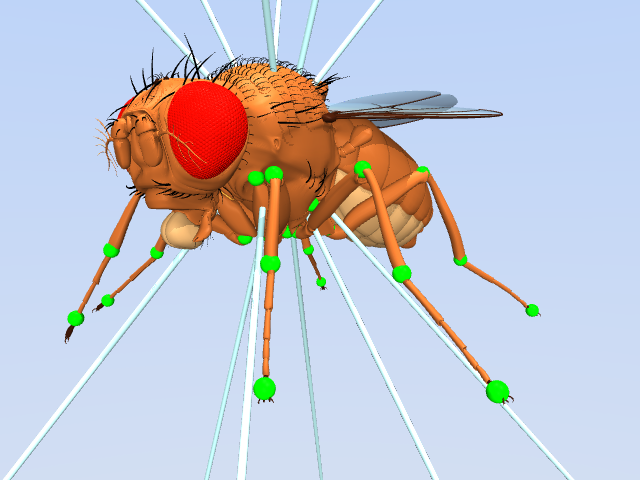

In [22]:
# physics = mjcf.Physics.from_mjcf_model(mjcf_model)
# physics.model.geom('floor').pos = (0, 0, -.137)
_ = physics.reset()
# Visualize model fitted to first frame.
scene_option = mujoco.wrapper.core.MjvOption()
scene_option.flags[enums.mjtVisFlag.mjVIS_CONTACTPOINT] = True
scene_option.flags[mujoco.mjtVisFlag.mjVIS_CONTACTFORCE] = True
pixels = physics.render(camera_id=0, width=640, height=480,scene_option=scene_option)
PIL.Image.fromarray(pixels)

# Try fitting all frames

In [23]:
_ = physics.reset()
# retract_wings(physics, prefix='')

site_pos = physics.named.data.site_xpos[site_names]
joints_to_manipulate = ['coxa_abduct_T1_left',  'coxa_twist_T1_left',   'coxa_T1_left',   'femur_T1_left',  'femur_twist_T1_left',  'tibia_T1_left',    'tarsus_T1_left',
                        'coxa_abduct_T1_right', 'coxa_twist_T1_right',  'coxa_T1_right',  'femur_T1_right', 'femur_twist_T1_right', 'tibia_T1_right',   'tarsus_T1_right',
                        'coxa_abduct_T2_left',  'coxa_twist_T2_left',   'coxa_T2_left',   'femur_T2_left',  'femur_twist_T2_left',  'tibia_T2_left',    'tarsus_T2_left',
                        'coxa_abduct_T2_right', 'coxa_twist_T2_right',  'coxa_T2_right',  'femur_T2_right', 'femur_twist_T2_right', 'tibia_T2_right',   'tarsus_T2_right',
                        'coxa_abduct_T3_left',  'coxa_twist_T3_left',   'coxa_T3_left',   'femur_T3_left',  'femur_twist_T3_left',  'tibia_T3_left',    'tarsus_T3_left',
                        'coxa_abduct_T3_right', 'coxa_twist_T3_right',  'coxa_T3_right',  'femur_T3_right', 'femur_twist_T3_right', 'tibia_T3_right',   'tarsus_T3_right',]

qpos = []
all_frames = []
n_frames = len(df[joint_pos_columns].values)
for i in tqdm(range(n_frames)):
    # Prepare frame for fitting.
    frame = df[joint_pos_columns].values[i, :].reshape(30, 3)  # (keypoint, xyz)
    frame = transform_frame(frame)
    frame += site_pos[0, :]  # Shift to body-coxa T1 left joint.
    all_frames.append(frame)
    # _ = physics.reset()
    # Run IK fit on current frame.
    res = qpos_from_site_xpos(physics, site_names, frame, joints_to_manipulate, inplace=True)
    # Store qpos results.
    qpos.append(res.qpos.copy())
all_frames = np.stack(all_frames)
qpos = np.stack(qpos)


100%|██████████| 181/181 [00:51<00:00,  3.53it/s]


In [26]:
np.max(np.abs(qpos[:,22]))

0.9301507006507926

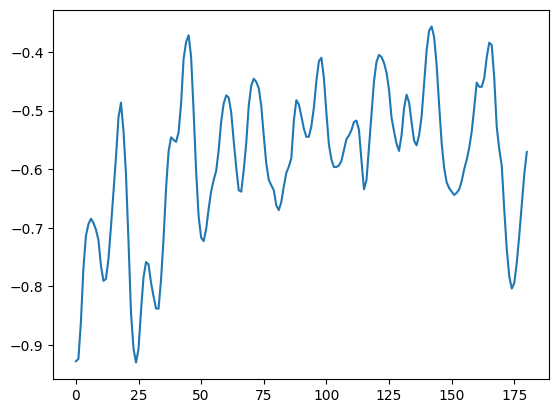

In [27]:
plt.plot(qpos[:,22])
plt.show()

In [28]:
physics.named.data.qpos['coxa_abduct_T2_left']

array([-1.83605521])

In [29]:
qpos.shape

(181, 42)

In [22]:
len(joints_to_manipulate)

42

In [20]:
# qpos_stand = qpos[0,:] #np.array([0,0,0,0,0,0,0,0, 0, 0.000178521, -1.07906e-05, 0, 0.00022365, 0.00012099, 0, 0, 0, 0, 0, 0, -8.21227e-05, 1.7515e-05, 0, -6.83271e-05, -1.73481e-05, 0, 0, 0, 0, 0, 0, -7.29514e-05, 8.13461e-05, 0, -4.55924e-05, 1.73673e-05, 0, 0, 0, 0, 0, 0, -0.000200893, 0.000243786, 0, -9.05341e-05, -1.9564e-05, 0, 0, 0, 0, 0, 0, 0.000307064, -0.000344922, 0, 2.74459e-05, 5.30669e-06, 0, 0, 0, 0, 0, 0, 0.000162806, -7.42181e-05, 0, 0.000232139, 7.99452e-05, 0, 0, 0, 0])
# qvel_stand = np.zeros((qpos_stand.shape[0]-1))
qvel = np.diff(qpos, axis=0, prepend=qpos[0:1,:])
qvel = qvel[:,1:]

In [21]:
interp_time = np.linspace(0,all_frames.shape[0],10*all_frames.shape[0])
time = np.linspace(0,all_frames.shape[0],all_frames.shape[0])
mod_frames = np.zeros((interp_time.shape[0],all_frames.shape[1],all_frames.shape[2]))
qpos_frames = np.zeros((interp_time.shape[0],qpos.shape[1]))
qvel_frames = np.zeros((interp_time.shape[0],qvel.shape[1]))
for n in range(all_frames.shape[1]):
    for m in range(all_frames.shape[2]):
        mod_frames[:,n,m] = np.interp(interp_time, time, all_frames[:,n,m])
for n in range(qpos.shape[1]):
    qpos_frames[:,n] = np.interp(interp_time, time, qpos[:,n])
for n in range(qvel.shape[1]):    
    qvel_frames[:,n] = np.interp(interp_time, time, qvel[:,n])


In [ ]:
mod_frames = all_frames
qpos_frames = qpos
qvel_frames = qvel

In [ ]:
# mod_frames = all_frames.copy()
mod_frames[:,:,-1] = mod_frames[:,:,-1]+0.021
mod_frames[:,:,-1] = np.clip(mod_frames[:,:,-1],-0.135,10)
print(np.min(mod_frames[:,:,-1]),np.max(mod_frames[:,:,-1]))

In [37]:
root = mjcf.RootElement()
root.keyframe.add('key', name=f'walk{walking_bout_n}_1', mpos=mod_frames[0].flatten(),qpos=qpos_frames[0].flatten(),qvel=qvel_frames[0].flatten())
for n in tqdm(range(2,mod_frames.shape[0])):
    root.keyframe.add('key', name=f'walk{walking_bout_n}_{n}', mpos=mod_frames[n].flatten(),qpos=qpos_frames[n].flatten())
    
# save xml file
keyframe_path = task_path / 'keyframes/'
mjcf.export_with_assets(root, keyframe_path, f'Fly_walk_pos{walking_bout_n}.xml')


100%|██████████| 1808/1808 [00:00<00:00, 35299.41it/s]


PosixPath('/Users/eabe/Research/MyRepos/mujoco_mpc/mjpc/tasks/fruitfly/flytracking/keyframes/Fly_walk1.xml')

In [22]:
root = mjcf.RootElement()
root.keyframe.add('key', name=f'walk{walking_bout_n}_1', mpos=mod_frames[0].flatten(),qpos=qpos[0].flatten(),qvel=qvel[0].flatten())
for n in range(2,mod_frames.shape[0]):
    root.keyframe.add('key', name=f'walk{walking_bout_n}_{n}', mpos=mod_frames[n].flatten())
    
# save xml file
keyframe_path = task_path / 'keyframes/'
mjcf.export_with_assets(root, keyframe_path,f'Fly_walk_free_qpos{walking_bout_n}.xml')
keyframe_path/f'Fly_walk_pos{walking_bout_n}.xml'

PosixPath('/Users/eabe/Research/MyRepos/mujoco_mpc/mjpc/tasks/fruitfly/flyqpos2/keyframes/Fly_walk_pos1.xml')

In [24]:
physics.named.data.qpos

FieldIndexer(qpos):
 0                 ball [ 1       ]
 1                 ball [ 0       ]
 2                 ball [ 0       ]
 3                 ball [ 0       ]
 4  coxa_abduct_T1_left [ 0.323   ]
 5   coxa_twist_T1_left [ 0.744   ]
 6         coxa_T1_left [ 0.424   ]
 7  femur_twist_T1_left [ 0.706   ]
 8        femur_T1_left [ 0.703   ]
 9        tibia_T1_left [ 0.131   ]
10       tarsus_T1_left [ 1.26    ]
11      tarsus2_T1_left [ 0       ]
12      tarsus3_T1_left [ 0       ]
13      tarsus4_T1_left [ 0       ]
14      tarsus5_T1_left [ 0       ]
15 coxa_abduct_T1_right [ 0.0995  ]
16  coxa_twist_T1_right [ 0.148   ]
17        coxa_T1_right [ 0.272   ]
18 femur_twist_T1_right [-0.535   ]
19       femur_T1_right [ 0.325   ]
20       tibia_T1_right [ 0.236   ]
21      tarsus_T1_right [ 1.28    ]
22     tarsus2_T1_right [ 0       ]
23     tarsus3_T1_right [ 0       ]
24     tarsus4_T1_right [ 0       ]
25     tarsus5_T1_right [ 0       ]
26  coxa_abduct_T2_left [-1.84    ]
27   cox

In [ ]:
_ = physics.reset()
t = 0
scene_option.sitegroup[:] = [1, 1, 1, 1, 1, 1]
physics.data.mocap_pos = mod_frames[t]
physics.data.qpos = qpos[t]
for t in range(10):
    physics.step()
pixels = physics.render(camera_id=1, width=640, height=480, scene_option=scene_option)
# qpos_stand = physics.named.data.qpos
# qvel_stand = physics.named.data.qvel
PIL.Image.fromarray(pixels)

In [ ]:
np.set_printoptions(suppress=True)
# print(["{:.02f}".format(qqpos) for qqpos in physics.data.qpos])

In [36]:
# Generate video of fitted poses.

camera_id = 1 # Side view.

# Hide all sites.
scene_option = mujoco.wrapper.core.MjvOption()
scene_option.sitegroup[:] = [1, 1, 1, 0, 0, 0]
scene_option.flags[enums.mjtVisFlag.mjVIS_CONTACTPOINT] = True
# scene_option.flags[mujoco.mjtVisFlag.mjVIS_CONTACTFORCE] = True


#retract_wings(physics)

video_frames = []
for q in tqdm(qpos):
    with physics.reset_context():
        physics.data.qpos = q.copy()
    pixels = physics.render(camera_id=camera_id, width=640, height=480, scene_option=scene_option)
    video_frames.append(pixels)

100%|██████████| 181/181 [00:02<00:00, 65.90it/s]


In [37]:
display_video(video_frames, framerate=30)

In [38]:
legs = ['T1_left', 'T1_right', 'T2_left', 'T2_right', 'T3_left', 'T3_right']
joints = ['coxa', 'femur', 'tibia', 'tarsus']
xpos_geoms = ['coxa', 'femur', 'tibia', 'tarsus', 'claw']
joint_names = [f'{joint}_{leg}' for leg in legs for joint in joints]
xpos_names = [f'{joint}_{leg}' for leg in legs for joint in xpos_geoms]
# physics.named.data.framepos[pos_names]
site_names = [f'tracking[{joint_name}]' for joint_name in xpos_names]

legs_data = ['L1', 'R1', 'L2','R2', 'L3','R3']
joints_data = ['A','B','C','D','E']
coords_data = ['_x','_y','_z']
joint_pos_columns = [leg + joint + coord 
                     for leg in legs_data
                     for joint in joints_data 
                     for coord in coords_data]

# Generate joint sequences in model and data in matching order

In [ ]:
# Model.
# mjcf_model = mjcf.from_path(xml_path)
# legs = ['T1_left', 'T1_right', 'T2_left', 'T2_right', 'T3_left', 'T3_right']
# joints = ['coxa', 'femur', 'tibia', 'tarsus', 'claw']
# joint_names = [f'{joint}_{leg}' for leg in legs for joint in joints]

# Data.
legs_data = ['L1', 'R1', 'L2','R2', 'L3','R3']
joints_data = ['A','B','C','D','E']
coords_data = ['_x','_y','_z']
joint_pos_columns = [leg + joint + coord 
                     for leg in legs_data
                     for joint in joints_data 
                     for coord in coords_data]

In [ ]:
for joint in joint_names:
    mjcf_model.find('joint', joint)


In [ ]:

bout_list = [14574,3962]
kp_tracking = {}
kp_tracking['joint_pos_columns'] = joint_pos_columns
for nbout,wbout in enumerate(bout_list):
    df = full_df[full_df['walking_bout_number'] == wbout]
    print(df.shape)
    kp_tracking['walking_{}'.format(nbout)] = df[joint_pos_columns].values.reshape(-1,30, 3)

(181, 452)
(601, 452)


In [ ]:
import io_dict_to_hdf5 as ioh5

In [ ]:
ioh5.save('kp_tracking.h5', kp_tracking)

# Visualize a single frame

Text(0.5, 1.0, 'side view')

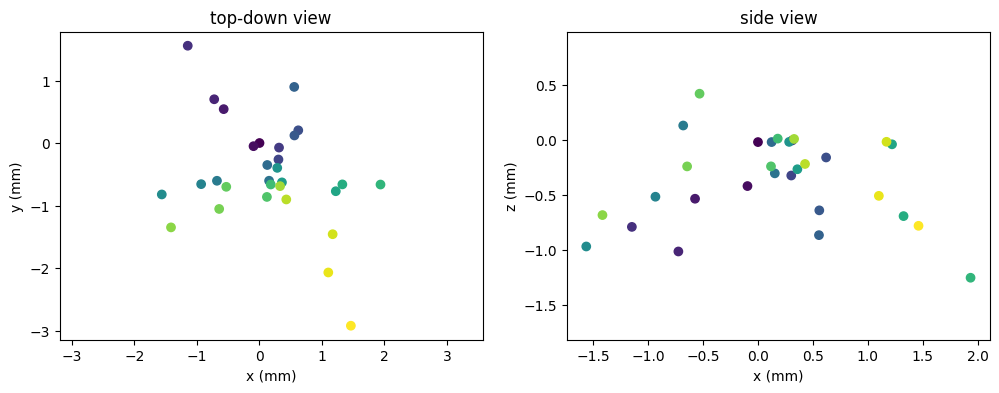

In [39]:
frame_idx = 0
test_frame = df[joint_pos_columns].values[frame_idx, :].reshape(30, 3)  # (keypoint, xyz)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.scatter(test_frame[:, 0], test_frame[:, 1], c=np.arange(30))
plt.axis('equal')
plt.xlabel('x (mm)')
plt.ylabel('y (mm)')
plt.title('top-down view')
plt.subplot(1, 2, 2)
plt.scatter(test_frame[:, 0], test_frame[:, 2], c=np.arange(30))
plt.axis('equal')
plt.xlabel('x (mm)')
plt.ylabel('z (mm)')
plt.title('side view')

# Compare model's initial position with first data frame

In [40]:
# Get the first frame.
frame0 = df[joint_pos_columns].values[0, :].reshape(30, 3)  # (keypoint, xyz)
frame0 = transform_frame(frame0)
site_pos = physics.named.data.site_xpos[site_names]
# Shift to match origin of data and model.
frame0 += site_pos[0, :]  # Body-coxa T1 left joint is the data origin.

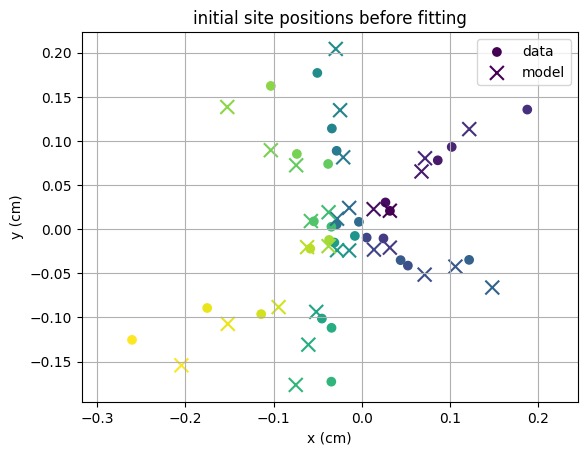

In [41]:
plt.scatter(frame0[:, 0], frame0[:, 1], c=np.arange(30), label='data')
plt.scatter(site_pos[:, 0], site_pos[:, 1], marker='x', s=100, c=np.arange(30), label='model')
plt.axis('equal')
plt.title('initial site positions before fitting')
plt.xlabel('x (cm)')
plt.ylabel('y (cm)')
plt.legend()
plt.grid()

# Try fitting one frame

In [42]:
# Manipulate all joints for now.
joints_to_manipulate = [j.name for j in mjcf_model.find_all('joint')]

In [43]:
frame0.shape, len(joints_to_manipulate), len(site_names)

((30, 3), 67, 30)

In [44]:
_ = physics.reset()
# retract_wings(physics, prefix='')

# Run IK fit on one frame.
res = qpos_from_site_xpos(physics, site_names, frame0, joints_to_manipulate, inplace=True)

In [45]:
res.qpos

array([ 1.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        7.26657972e-01,  7.12491381e-01,  1.16169070e+00,  4.82009690e-01,
        1.54882514e+00,  1.07605961e+00,  8.93172535e-01,  3.37992709e-02,
        2.13222045e-02,  1.02844574e-01, -7.72887057e-02,  2.13273888e-01,
        3.57020717e-01, -1.14704816e-01, -3.02362720e-01,  4.74595141e-02,
       -3.69337190e-01,  1.33167944e+00, -4.39007900e-02, -5.54659753e-02,
       -2.69511919e-01, -1.14094715e+00, -4.56040002e-01, -1.37832969e+00,
        5.93447424e-01, -1.01979708e+00,  3.58561953e-01, -4.24521930e-02,
        1.42068367e-02,  1.93028930e-02,  7.61831698e-03,  1.75633146e-02,
        2.42542140e-04, -1.49004416e+00, -9.26580240e-01,  1.60947923e+00,
       -1.13089872e+00,  1.03033698e+00, -1.64708312e-01,  9.06886079e-02,
        3.91013277e-03,  1.76315017e-02,  6.91484719e-02,  5.63366539e-02,
        5.36379246e-01,  2.14566970e-01,  6.30406560e-01, -6.41851140e-01,
       -2.91368205e-01, -

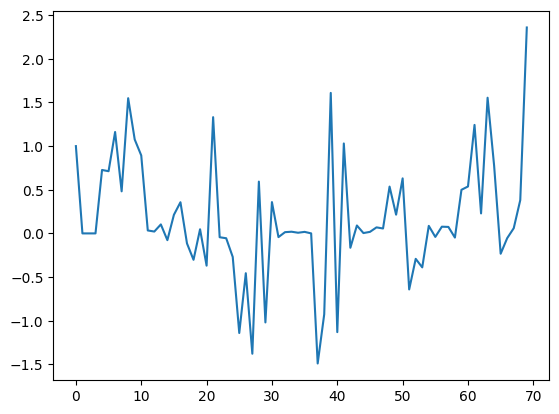

In [46]:
plt.plot(res.qpos)


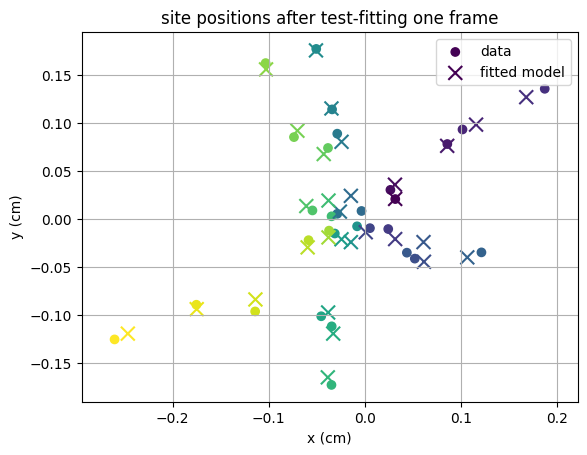

In [47]:
# Compare site positions after fitting.
site_pos = physics.named.data.site_xpos[site_names]
plt.scatter(frame0[:, 0], frame0[:, 1], c=np.arange(30), label='data')
plt.scatter(site_pos[:, 0], site_pos[:, 1], marker='x', s=100, c=np.arange(30), label='fitted model')
plt.axis('equal')
plt.title('site positions after test-fitting one frame')
plt.xlabel('x (cm)')
plt.ylabel('y (cm)')
plt.legend()
plt.grid()

In [48]:
# #add ball
# texture = mjcf_model.asset.add('texture', rgb1=[.2, .3, .4], rgb2=[.1, .2, .3],
#                                type='2d', builtin='checker', name='groundplane',
#                                width=200, height=200,)
# material = mjcf_model.asset.add('material', name='ballsurface', 
#                                 texrepeat=[2, 2],  # Makes white squares exactly 1x1 length units.
#                                 texuniform=True,
#                                 reflectance=0.2,
#                                 texture=texture)

# # Remove freejoint.
# freejoint = mjcf_model.find('joint', 'free')
# if freejoint is not None:
#     freejoint.remove()
    
# # == Add ball.
# radius = 0.454  # Pick ball radius.
# # Calculate ball position wrt fly given ball radius.
# claw_T1_left = np.array([0.09178167, 0.08813114, -0.12480448])
# ball_x = - 0.05
# ball_z = - np.sqrt(radius**2 
#                    - (claw_T1_left[0] - ball_x)**2 
#                    - claw_T1_left[1]**2) + claw_T1_left[2]
# ball = mjcf_model.worldbody.add('body', name='ball', pos=(ball_x, 0, ball_z))
# ball.add('geom', type='sphere', size=(radius, 0, 0),
#          material=material, density=0.1)  # Density of water in cgs == 1.
# ball_joint = ball.add('joint', name='ball', type='ball')

# # Exclude "surprising collisions".
# for child in mjcf_model.find('body', 'thorax').all_children():
#     if child.tag == 'body':
#         mjcf_model.contact.add('exclude', name=f'thorax_{child.name}',
#                                body1='thorax', body2=child.name)

In [ ]:
for n in range(1, 100):
    physics.step()

In [ ]:
# physics = mjcf.Physics.from_mjcf_model(mjcf_model)
# physics.model.geom('floor').pos = (0, 0, -.137)
_ = physics.reset()
# Visualize model fitted to first frame.
scene_option = mujoco.wrapper.core.MjvOption()
scene_option.flags[enums.mjtVisFlag.mjVIS_CONTACTPOINT] = True
scene_option.flags[mujoco.mjtVisFlag.mjVIS_CONTACTFORCE] = True
pixels = physics.render(camera_id=0, width=640, height=480,scene_option=scene_option)
PIL.Image.fromarray(pixels)

# Try fitting all frames

In [11]:
_ = physics.reset()
# retract_wings(physics, prefix='')

site_pos = physics.named.data.site_xpos[site_names]
joints_to_manipulate = ['coxa_abduct_T1_left',  'coxa_twist_T1_left',   'coxa_T1_left',   'femur_T1_left',  'femur_twist_T1_left',  'tibia_T1_left',    'tarsus_T1_left',
                        'coxa_abduct_T1_right', 'coxa_twist_T1_right',  'coxa_T1_right',  'femur_T1_right', 'femur_twist_T1_right', 'tibia_T1_right',   'tarsus_T1_right',
                        'coxa_abduct_T2_left',  'coxa_twist_T2_left',   'coxa_T2_left',   'femur_T2_left',  'femur_twist_T2_left',  'tibia_T2_left',    'tarsus_T2_left',
                        'coxa_abduct_T2_right', 'coxa_twist_T2_right',  'coxa_T2_right',  'femur_T2_right', 'femur_twist_T2_right', 'tibia_T2_right',   'tarsus_T2_right',
                        'coxa_abduct_T3_left',  'coxa_twist_T3_left',   'coxa_T3_left',   'femur_T3_left',  'femur_twist_T3_left',  'tibia_T3_left',    'tarsus_T3_left',
                        'coxa_abduct_T3_right', 'coxa_twist_T3_right',  'coxa_T3_right',  'femur_T3_right', 'femur_twist_T3_right', 'tibia_T3_right',   'tarsus_T3_right',]

qpos = []
all_frames = []
n_frames = len(df[joint_pos_columns].values)
for i in tqdm(range(n_frames)):
    # Prepare frame for fitting.
    frame = df[joint_pos_columns].values[i, :].reshape(30, 3)  # (keypoint, xyz)
    frame = transform_frame(frame)
    frame += site_pos[0, :]  # Shift to body-coxa T1 left joint.
    all_frames.append(frame)
    # _ = physics.reset()
    # Run IK fit on current frame.
    res = qpos_from_site_xpos(physics, site_names, frame, joints_to_manipulate, inplace=True)
    # Store qpos results.
    qpos.append(res.qpos.copy())
all_frames = np.stack(all_frames)
qpos = np.stack(qpos)


100%|██████████| 181/181 [00:52<00:00,  3.45it/s]


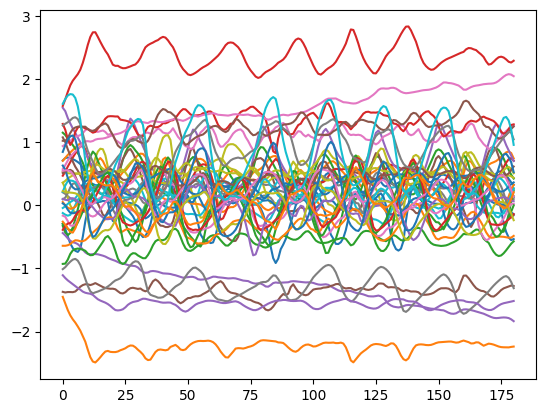

In [18]:
plt.plot(qpos[:,:])
plt.show()

In [ ]:
len(joints_to_manipulate)

In [19]:
# qpos_stand = qpos[0,:] #np.array([0,0,0,0,0,0,0,0, 0, 0.000178521, -1.07906e-05, 0, 0.00022365, 0.00012099, 0, 0, 0, 0, 0, 0, -8.21227e-05, 1.7515e-05, 0, -6.83271e-05, -1.73481e-05, 0, 0, 0, 0, 0, 0, -7.29514e-05, 8.13461e-05, 0, -4.55924e-05, 1.73673e-05, 0, 0, 0, 0, 0, 0, -0.000200893, 0.000243786, 0, -9.05341e-05, -1.9564e-05, 0, 0, 0, 0, 0, 0, 0.000307064, -0.000344922, 0, 2.74459e-05, 5.30669e-06, 0, 0, 0, 0, 0, 0, 0.000162806, -7.42181e-05, 0, 0.000232139, 7.99452e-05, 0, 0, 0, 0])
# qvel_stand = np.zeros((qpos_stand.shape[0]-1))
qvel = np.diff(qpos, axis=0, prepend=qpos[0:1,:])
# qvel = qvel[:,1:]

In [21]:
interp_time = np.linspace(0,all_frames.shape[0],10*all_frames.shape[0])
time = np.linspace(0,all_frames.shape[0],all_frames.shape[0])
mod_frames = np.zeros((interp_time.shape[0],all_frames.shape[1],all_frames.shape[2]))
qpos_frames = np.zeros((interp_time.shape[0],qpos.shape[1]))
qvel_frames = np.zeros((interp_time.shape[0],qvel.shape[1]))
for n in range(all_frames.shape[1]):
    for m in range(all_frames.shape[2]):
        mod_frames[:,n,m] = np.interp(interp_time, time, all_frames[:,n,m])
for n in range(qpos.shape[1]):
    qpos_frames[:,n] = np.interp(interp_time, time, qpos[:,n])
for n in range(qvel.shape[1]):    
    qvel_frames[:,n] = np.interp(interp_time, time, qvel[:,n])


In [14]:
mod_frames = all_frames
qpos_frames = qpos
qvel_frames = qvel

In [14]:
# mod_frames = all_frames.copy()
mod_frames[:,:,-1] = mod_frames[:,:,-1]+0.021
mod_frames[:,:,-1] = np.clip(mod_frames[:,:,-1],-0.135,10)
print(np.min(mod_frames[:,:,-1]),np.max(mod_frames[:,:,-1]))

-0.13147021216983024 0.03604049843334817


In [22]:
root = mjcf.RootElement()
root.keyframe.add('key', name=f'walk{walking_bout_n}_1', mpos=mod_frames[0].flatten(),qpos=qpos_frames[0].flatten(),qvel=qvel_frames[0].flatten())
for n in tqdm(range(2,mod_frames.shape[0])):
    root.keyframe.add('key', name=f'walk{walking_bout_n}_{n}', mpos=mod_frames[n].flatten(),qpos=qpos_frames[n].flatten())
    
# save xml file
keyframe_path = task_path / 'keyframes/'
mjcf.export_with_assets(root, keyframe_path, f'Fly_walk_free_qpos{walking_bout_n}.xml')
keyframe_path/f'Fly_walk_qpos{walking_bout_n}.xml'

100%|██████████| 1808/1808 [00:00<00:00, 17355.71it/s]


PosixPath('/Users/eabe/Research/MyRepos/mujoco_mpc/mjpc/tasks/fruitfly/flyqpos2/keyframes/Fly_walk_qpos1.xml')

In [ ]:
root = mjcf.RootElement()
root.keyframe.add('key', name=f'walk{walking_bout_n}_1', mpos=mod_frames[0].flatten(),qpos=qpos[0].flatten(),qvel=qvel.flatten())
for n in range(2,mod_frames.shape[0]):
    root.keyframe.add('key', name=f'walk{walking_bout_n}_{n}', mpos=mod_frames[n].flatten())
    
# save xml file
keyframe_path = task_path / 'keyframes/'
mjcf.export_with_assets(root, keyframe_path,f'Fly_walk_free_pos{walking_bout_n}.xml')
keyframe_path/f'Fly_walk_pos{walking_bout_n}.xml'

In [23]:
physics.named.data.qpos

FieldIndexer(qpos):
 0  coxa_abduct_T1_left [ 0       ]
 1   coxa_twist_T1_left [ 0       ]
 2         coxa_T1_left [ 0       ]
 3  femur_twist_T1_left [ 0       ]
 4        femur_T1_left [ 0       ]
 5        tibia_T1_left [ 0       ]
 6       tarsus_T1_left [ 0       ]
 7 coxa_abduct_T1_right [ 0       ]
 8  coxa_twist_T1_right [ 0       ]
 9        coxa_T1_right [ 0       ]
10 femur_twist_T1_right [ 0       ]
11       femur_T1_right [ 0       ]
12       tibia_T1_right [ 0       ]
13      tarsus_T1_right [ 0       ]
14  coxa_abduct_T2_left [ 0       ]
15   coxa_twist_T2_left [ 0       ]
16         coxa_T2_left [ 0       ]
17  femur_twist_T2_left [ 0       ]
18        femur_T2_left [ 0       ]
19        tibia_T2_left [ 0       ]
20       tarsus_T2_left [ 0       ]
21 coxa_abduct_T2_right [ 0       ]
22  coxa_twist_T2_right [ 0       ]
23        coxa_T2_right [ 0       ]
24 femur_twist_T2_right [ 0       ]
25       femur_T2_right [ 0       ]
26       tibia_T2_right [ 0       ]
27      

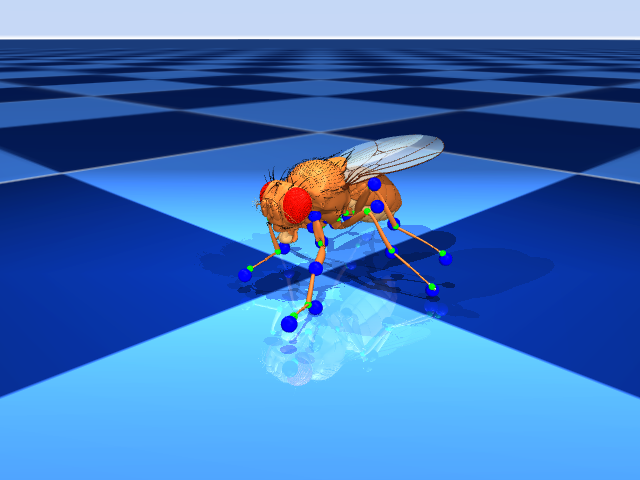

In [24]:
_ = physics.reset()
t = 0
scene_option = mujoco.wrapper.core.MjvOption()

scene_option.sitegroup[:] = [1, 1, 1, 1, 1, 1]
physics.data.mocap_pos = mod_frames[t]
physics.data.qpos = qpos_frames[t]
for t in range(1):
    physics.step()
pixels = physics.render(camera_id=1, width=640, height=480, scene_option=scene_option)
# qpos_stand = physics.named.data.qpos
# qvel_stand = physics.named.data.qvel
PIL.Image.fromarray(pixels)

In [29]:
qpos_frames[0]

array([ 1.        ,  0.        ,  0.        ,  0.        ,  0.71071082,
        0.70564527,  1.15071647,  0.46882233,  1.54587726,  1.07667864,
        0.93840932,  0.        ,  0.        ,  0.        ,  0.        ,
        0.20553661,  0.35831552, -0.12265076, -0.29346072,  0.05123722,
       -0.32732257,  1.28953044,  0.        ,  0.        ,  0.        ,
        0.        , -0.43903277, -1.37117907,  0.57616647, -1.01173094,
        0.35731038, -0.04266885,  0.03068078,  0.        ,  0.        ,
        0.        ,  0.        , -1.45055976, -0.92799723,  1.57501263,
       -1.10791237,  1.02273605, -0.16358902,  0.09628786,  0.        ,
        0.        ,  0.        ,  0.        ,  0.53623237,  0.2149385 ,
        0.63010391, -0.64134032, -0.29137382, -0.38844405,  0.10042321,
        0.        ,  0.        ,  0.        ,  0.        ,  0.51129319,
        0.54633876,  1.26554611,  0.22622473,  1.60827045,  0.84605318,
       -0.25980456,  0.        ,  0.        ,  0.        ,  0.  

In [ ]:
np.set_printoptions(suppress=True)
# print(["{:.02f}".format(qqpos) for qqpos in physics.data.qpos])

In [23]:
import io_dict_to_hdf5 as ioh5
bout_dict = ioh5.load('./bout_dict.h5')

In [28]:
qpos = bout_dict['walking_bout{:02}'.format(0)]['inv_qpos']
qpos.shape

(601, 70)

(66,)

In [25]:
# Generate video of fitted poses.

camera_id = 1 # Side view.

# Hide all sites.
scene_option = mujoco.wrapper.core.MjvOption()
scene_option.sitegroup[:] = [1, 1, 1, 1, 1, 0]
# scene_option.flags[enums.mjtVisFlag.mjVIS_CONTACTPOINT] = True
# scene_option.flags[mujoco.mjtVisFlag.mjVIS_CONTACTFORCE] = True


#retract_wings(physics)

video_frames = []
for t,q in tqdm(enumerate(qpos_frames)):
    with physics.reset_context():
        physics.data.qpos = qpos_frames[t].copy()
        physics.data.mocap_pos = mod_frames[t]
    pixels = physics.render(camera_id=camera_id, width=640, height=480, scene_option=scene_option)
    video_frames.append(pixels)

1810it [00:36, 49.26it/s]


In [26]:
display_video(video_frames, framerate=50)

In [33]:
np.min(mod_frames[:,:,-1]),np.max(mod_frames[:,:,-1])

(-0.15247021216983023, 0.015040498433348166)

In [ ]:
# Visualize fly standing
physics.reset()

scene_option = mujoco.wrapper.core.MjvOption()
scene_option.sitegroup[:] = [1, 1, 1, 1, 1, 1]
scene_option.flags[enums.mjtVisFlag.mjVIS_CONTACTPOINT] = True
scene_option.flags[mujoco.mjtVisFlag.mjVIS_CONTACTFORCE] = True
physics.data.qpos = np.zeros(qpos.shape[1])
# for n in range(1):
#     physics.step()

mod_frames_stand = np.stack([physics.named.data.xpos[xpos_names[n]] for n in range(len(xpos_names))])[None,:,:]
physics.data.mocap_pos = mod_frames_stand[0]

scene_option = mujoco.wrapper.core.MjvOption()
scene_option.sitegroup[:] = [1, 1, 1, 1, 1, 1]
scene_option.flags[enums.mjtVisFlag.mjVIS_CONTACTPOINT] = True
scene_option.flags[mujoco.mjtVisFlag.mjVIS_CONTACTFORCE] = True
for n in range(1):
    physics.step()
    
pixels = physics.render(camera_id=1, width=640, height=480,scene_option=scene_option)
PIL.Image.fromarray(pixels)

In [ ]:
t = 0
qpos_stand = physics.named.data.qpos
qvel_stand = np.zeros((qpos_stand.shape[0]-1))
root = mjcf.RootElement()
root.keyframe.add('key', name=f'stand{walking_bout_n}_1', mpos=mod_frames_stand[0].flatten(),qpos=qpos_stand.flatten(),qvel=qvel_stand.flatten())
for n in range(2,100):
    root.keyframe.add('key', name=f'stand{walking_bout_n}_{n}', mpos=mod_frames_stand[0].flatten(),qpos=qpos_stand.flatten())
    
# save xml file
root.default.remove()
keyframe_path = task_path / 'keyframes/'
mjcf.export_with_assets(root, keyframe_path,f'Fly_stand_free_qpos{walking_bout_n}.xml')
keyframe_path/f'Fly_stand_qpos{walking_bout_n}.xml'

In [ ]:
plt.plot(physics.data.xpos[:,0], physics.data.xpos[:,1], 'o')
plt.plot(mod_frames_stand[0,:,0], mod_frames_stand[0,:,1], 'x')

In [32]:
import pickle
import numpy as np
from pathlib import Path
from typing import Union, Dict

stac_data = Path('/Users/eabe/Research/MyRepos/mujoco_mpc/Archive/fruitfly/transform.p')

In [33]:
# Load data
with open(stac_data, "rb") as file:
    d = pickle.load(file)
    qposes = np.array(d["qpos"])
    kp_data = np.array(d["kp_data"])
    kp_names = d["kp_names"]
    offsets = d["offsets"]

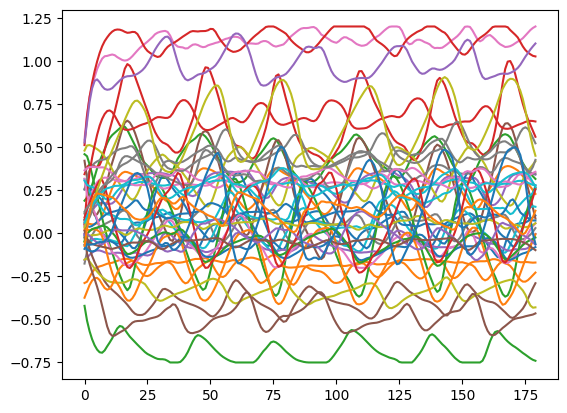

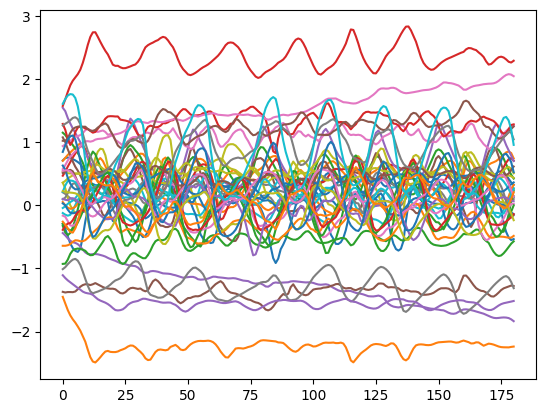

In [40]:
plt.figure()
plt.plot(qposes[:180,7:])
plt.figure()
plt.plot(qpos)
plt.show()